<a href="https://colab.research.google.com/github/kjamison/brainmontageplot/blob/main/brainmontageplot_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#may need to restart the runtime and run again after the first time this installs new packages
import sys
# if 'brainmontage' not in sys.modules:
  # !pip install git+https://github.com/kjamison/brainmontageplot.git

!pip install git+https://github.com/kjamison/brainmontageplot.git@dd898f1



import numpy as np
from brainmontage import create_montage_figure, save_image
import matplotlib as mpl
from matplotlib import pyplot as plt


  Cloning https://github.com/kjamison/brainmontageplot.git (to revision dd898f1) to /private/var/folders/q3/3wds1cgn0hsd3rxjy8y8p2cc0000gp/T/pip-req-build-j7si2whd
  Running command git clone --filter=blob:none --quiet https://github.com/kjamison/brainmontageplot.git /private/var/folders/q3/3wds1cgn0hsd3rxjy8y8p2cc0000gp/T/pip-req-build-j7si2whd
  Did not find branch or tag 'dd898f1', assuming revision or ref.
  Running command git checkout -q dd898f1
  Resolved https://github.com/kjamison/brainmontageplot.git to commit dd898f1
  Preparing metadata (setup.py) ... done
  Using cached matplotlib-3.10.7-cp310-cp310-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached nibabel-5.3.2-py3-none-any.whl.metadata (9.1 kB)
  Using cached nilearn-0.12.1-py3-none-any.whl.metadata (9.9 kB)
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pillow-12.0.0-cp310-cp310-macosx_11_0_ar

[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
CPU times: user 369 ms, sys: 59.7 ms, total: 429 ms
Wall time: 523 ms


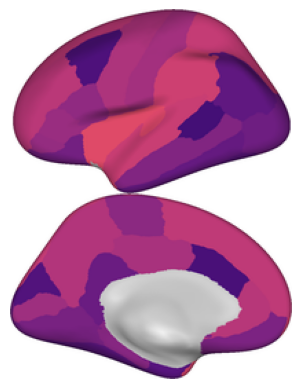

In [3]:
%%time

roivals=np.arange(86)+1 #example values for each ROI (1-numroi)

img=create_montage_figure(roivals,atlasname='fs86',
    viewnames=['lateral','medial'],surftype='infl',clim=[0,86],colormap='magma',hemis=['lh'])

save_image(img,'mydata_montage.pdf')
#or you can add outputimagefile='mydata_montage.png' to create_montage_figure() to save directly

plt.figure()
plt.imshow(img)
_=plt.axis('off')


Using random colormap with 1056 entries.
[fetch_surf_fsaverage] Added README.md to /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data
[fetch_surf_fsaverage] Dataset created in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
[fetch_surf_fsaverage] Downloading data from https://osf.io/svf8k/download ...
Downloaded 10420224 of 34242788 bytes (30.4%%,    2.3s remaining)
[fetch_surf_fsaverage]  ...done. (8 seconds, 0 min)

[fetch_surf_fsaverage] Extracting data from /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage/735bf0f211246c83396b5f21f706c224/download...
[fetch_surf_fsaverage] .. done.

Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved test_4S1056_random.png


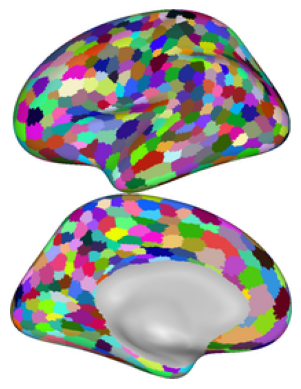

In [2]:
roivals=np.arange(1056)+1 #for example
img=create_montage_figure(roivals,atlasname='cifti91k',subparcfile='/Users/sps253/Desktop/atlases/atlas-4S1056Parcels/atlas-4S1056Parcels_space-fsLR_den-91k_dseg.dlabel.nii',
    viewnames=['lateral','medial'],surftype='infl',clim=[0,1056],colormap='random',outputimagefile='test_4S1056_random.png',hemis=['lh'],face_mode='best')

plt.figure()
plt.imshow(img)
_=plt.axis('off')

Saved mydata_montage_withslices_and_colorbar.png
CPU times: user 6.28 s, sys: 310 ms, total: 6.6 s
Wall time: 18.3 s


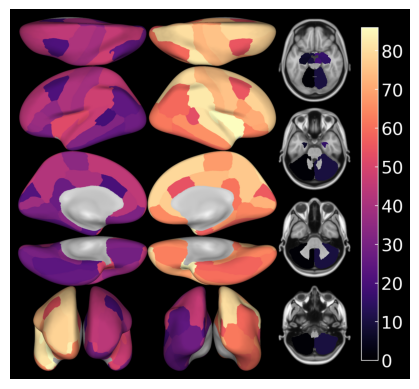

In [10]:
%%time
#create an image with surface views, upscaled to higher dpi (1 instead of 0.25),
# a vertical row of axial slices, with black background
img_with_slices=create_montage_figure(roivals,atlasname='fs86',
    viewnames='all',surftype='infl',clim=[0,86],colormap='magma',
    slice_dict={'axial':[23,33,43,53]},mosaic_dict={'axial':[-1,1]},
    upscale_factor=2, backgroundcolor="black",face_mode='best',
    add_colorbar=True, colorbar_color='white', colorbar_fontsize=20,
    outputimagefile='mydata_montage_withslices_and_colorbar.png')

plt.figure()
plt.imshow(img_with_slices,cmap='magma',vmin=0,vmax=86)
_=plt.axis('off')


Saved mydata_montage_onlyslices.png
CPU times: user 3.87 s, sys: 234 ms, total: 4.11 s
Wall time: 6.73 s


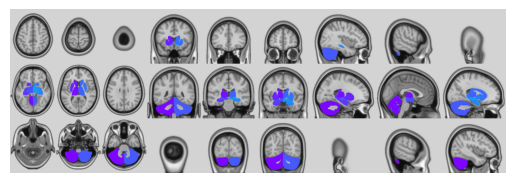

In [11]:
%%time
#Or an image with axial, coronal, and sagittal slices only, and a light gray background
img_slices=create_montage_figure(roivals,atlasname='fs86',
    viewnames='none',clim=[0,86],colormap='rainbow',
    slice_dict={'axial':range(0,180,20),'coronal':range(20,200,20),'sagittal':range(10,180,20)},
    backgroundcolor="lightgray",
    outputimagefile='mydata_montage_onlyslices.png')

plt.figure()
plt.imshow(img_slices)
_=plt.axis('off')


For cmapfile=lut, override input values and clim to display LUT colormap: /usr/local/lib/python3.10/dist-packages/brainmontage/atlases/fs86_LUT.txt.
For cmapfile=lut, override input values and clim to display LUT colormap: /usr/local/lib/python3.10/dist-packages/brainmontage/atlases/fs86_LUT.txt.
For cmapfile=lut, override input values and clim to display LUT colormap: /usr/local/lib/python3.10/dist-packages/brainmontage/atlases/shen268_LUT.txt.
For cmapfile=lut, override input values and clim to display LUT colormap: /usr/local/lib/python3.10/dist-packages/brainmontage/atlases/schaefer100_7Networks_LUT.txt.
For cmapfile=lut, override input values and clim to display LUT colormap: /usr/local/lib/python3.10/dist-packages/brainmontage/atlases/schaefer200_7Networks_LUT.txt.
For cmapfile=lut, override input values and clim to display LUT colormap: /usr/local/lib/python3.10/dist-packages/brainmontage/atlases/schaefer300_7Networks_LUT.txt.
For cmapfile=lut, override input values and clim to 

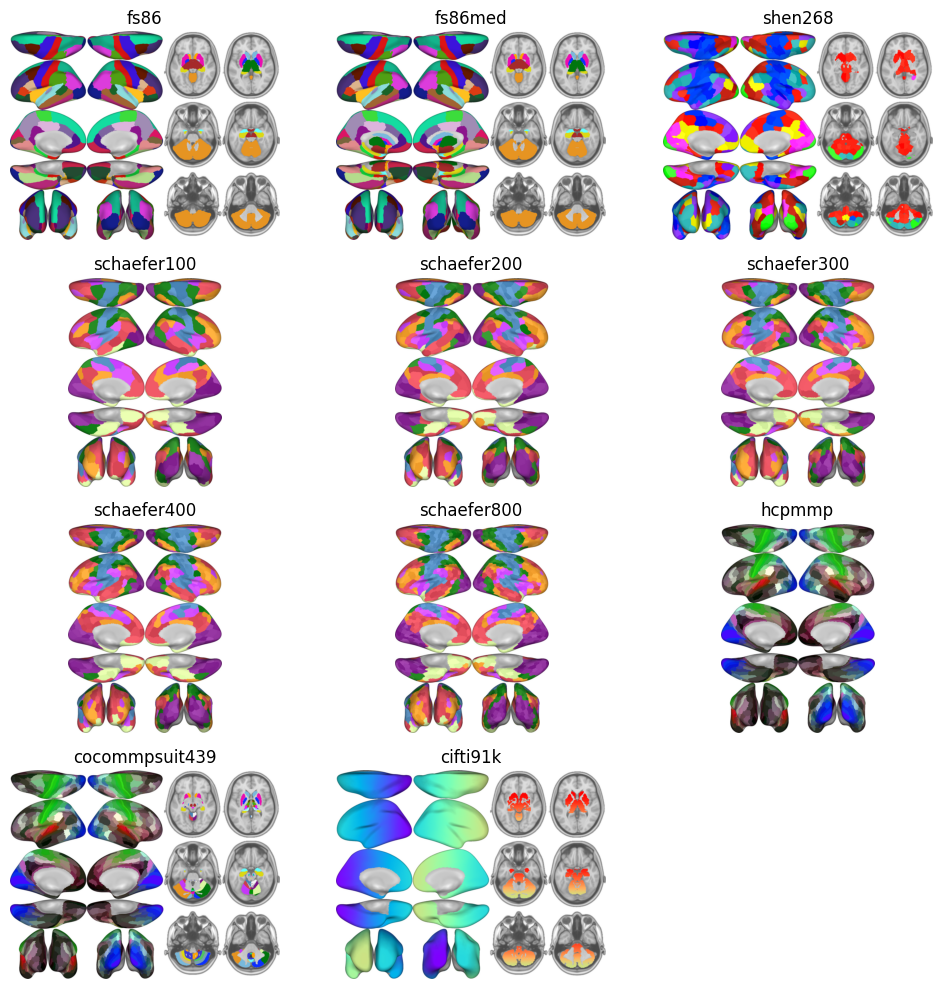

In [12]:
%%time
#loop through and display all available atlases, using colors from their LUT

from brainmontage import retrieve_atlas_info

atlaslist=retrieve_atlas_info('list')
fig=plt.figure(figsize=(10,10))
for i,a in enumerate(atlaslist):
  atlasinfo=retrieve_atlas_info(a)
  if atlasinfo['subcorticalvolume']:
    sliceparams={'slice_dict':{'axial':[23,33,43,53,63,73]},
                 'mosaic_dict':{'axial':[-1,2]},
                 'slice_background_alpha':.75}
  else:
    sliceparams={}
  img=create_montage_figure(roivals=None,atlasname=a,colormap='lut',**sliceparams)
  ax=plt.subplot(int(np.ceil(np.sqrt(len(atlaslist)))),int(np.floor(np.sqrt(len(atlaslist)))),i+1)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(a)

fig.tight_layout()

2025-10-16 14:41:29 URL:https://raw.githubusercontent.com/kjamison/brainmontageplot/main/examples/S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii [997032/997032] -> "S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii" [1]
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
CPU times: user 1.56 s, sys: 241 ms, total: 1.8 s
Wall time: 3.25 s


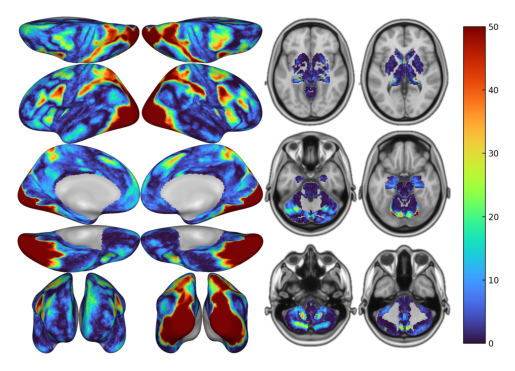

In [6]:
%%time
#example of reading and displaying cifti91k data

#Download example cifti map from HCP Retinotopy dataset (https://balsa.wustl.edu/study/9Zkk)
!wget -nv -O S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii https://github.com/kjamison/brainmontageplot/raw/main/examples/S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii

import nibabel as nib
ciftidata=nib.load("S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii").get_fdata()[0,:]

img=create_montage_figure(roivals=ciftidata,atlasname="cifti91k",colormap="turbo",clim=[0,50],
                          slice_dict={'axial':[23,33,43,53,63,73]},mosaic_dict={'axial':[-1,2]},
                          add_colorbar=True, upscale_factor=2)
plt.figure()
plt.imshow(img)
_=plt.axis('off')

<timed exec>:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
CPU times: user 668 ms, sys: 62.4 ms, total: 730 ms
Wall time: 743 ms


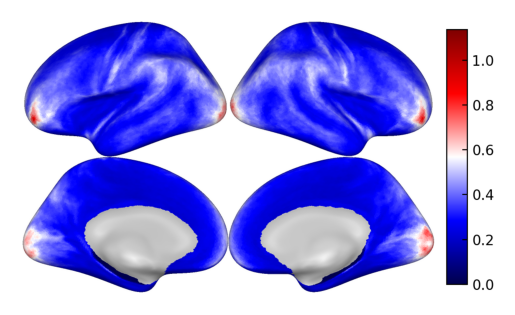

In [3]:
%%time
#example of reading and displaying cifti91k data

# #Download example cifti map from HCP Retinotopy dataset (https://balsa.wustl.edu/study/9Zkk)
# !wget -nv -O S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii https://github.com/kjamison/brainmontageplot/raw/main/examples/S1200_7T_Retinotopy181.Fit3_R2_MSMAll.32k_fs_LR.dscalar.nii

import nibabel as nib
ciftidata=nib.load("/Users/sps253/Desktop/data/group-alff_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii").get_fdata()[0,:]

cmap = mpl.cm.get_cmap("seismic").copy()
cmap.set_bad(color="none")  # Transparent for NaN
img=create_montage_figure(roivals=ciftidata,atlasname="cifti91k",colormap=cmap,#clim=[0,50],
                          #slice_dict={'axial':[23,33,43,53,63,73]},mosaic_dict={'axial':[-1,2]},
                          add_colorbar=True, upscale_factor=2,
                          viewnames=['lateral','medial'],face_mode='best')
plt.figure()
plt.imshow(img)
_=plt.axis('off')


In [6]:
%%time
# Loop over CIFTI/GIFTI .nii atlases and generate surface montages
# - Discovers: /Users/sps253/Desktop/atlases/*/*.nii
# - For each file, computes max label (ignoring NaNs) and sets roivals=1..max_label
# - Uses cifti91k atlas for fsLR 91k surfaces; adjust if needed

import os, glob
# import numpy as np
# import nibabel as nib
# from matplotlib import pyplot as plt
# from brainmontage import create_montage_figure, save_image

atlas_roots = glob.glob('/Users/sps253/Desktop/atlases/*/*.nii')
print(f"Found {len(atlas_roots)} .nii files")

# Output directory (next to each .nii)
for nii_path in atlas_roots:
    try:
        # print(nii_path)
        img_nii = nib.load(nii_path)
        data = img_nii.get_fdata()
        # Handle possible leading map dimension(s); flatten across maps if present
        if data.ndim >= 2:
            # CIFTI dlabel/dscalar usually [maps x vertices]; use max across all maps
            data_flat = np.asarray(data).reshape(-1)
        else:
            data_flat = np.asarray(data)
        # Exclude NaN and negative if labels are non-negative (keep 0 as background)
        finite_vals = data_flat[np.isfinite(data_flat)]
        if finite_vals.size == 0:
            print(f"Skip (no finite data): {nii_path}")
            continue
        max_label = int(np.nanmax(finite_vals))
        if max_label < 1:
            print(f"Skip (no positive labels): {nii_path}")
            continue
        roivals = np.arange(max_label) + 1

        # Derive output filename next to source
        base = os.path.splitext(os.path.basename(nii_path))[0]
        out_png = os.path.join(os.path.dirname(nii_path), f"{base}_montage.png")

        img = create_montage_figure(
            roivals,
            atlasname='cifti91k',
            subparcfile=nii_path,
            viewnames=['lateral','medial'],
            surftype='infl',
            clim=[0, max_label],
            colormap='random',
            hemis=['lh'],
            face_mode='best',
            upscale_factor=2,
            add_colorbar=False,
            outputimagefile=out_png
        )
        # If not saved internally, also save here
        try:
            if img is not None:
                save_image(img, out_png)
        except Exception:
            pass

        print(f"Saved: {out_png}")
    except Exception as e:
        print(f"Error processing {nii_path}: {e}")

plt.close('all')


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Found 15 .nii files
Using random colormap with 360 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved /Users/sps253/Desktop/atlases/atlas-Glasser/atlas-Glasser_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Desktop/atlases/atlas-Glasser/atlas-Glasser_space-fsLR_den-91k_dseg.dlabel_montage.png
Using random colormap with 956 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved /Users/sps253/Desktop/atlases/atlas-4S956Parcels/atlas-4S956Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Desktop/atlases/atlas-4S956Parcels/atlas-4S956Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Using random colormap with 856 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/br

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Saved /Users/sps253/Desktop/atlases/atlas-4S1056Parcels/atlas-4S1056Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Desktop/atlases/atlas-4S1056Parcels/atlas-4S1056Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Using random colormap with 60 entries.


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Error processing /Users/sps253/Desktop/atlases/atlas-HCP/atlas-HCP_space-fsLR_den-91k_dseg.dlabel.nii: Subparc file must match atlas dimensions. Found 31870, expected 91282.
Using random colormap with 156 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Saved /Users/sps253/Desktop/atlases/atlas-4S156Parcels/atlas-4S156Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Desktop/atlases/atlas-4S156Parcels/atlas-4S156Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Using random colormap with 333 entries.
Error processing /Users/sps253/Desktop/atlases/atlas-Gordon/atlas-Gordon_space-fsLR_den-91k_dseg.dlabel.nii: Subparc file must match atlas dimensions. Found 64984, expected 91282.
Using random colormap with 80 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved /Users/sps253/Desktop/atlases/atlas-MIDB/atlas-MIDB_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Desktop/atlases/atlas-MIDB/atlas-MIDB_space-fsLR_den-91k_dseg.dlabel_montage.png
Using random colormap with 50 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brai

[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage


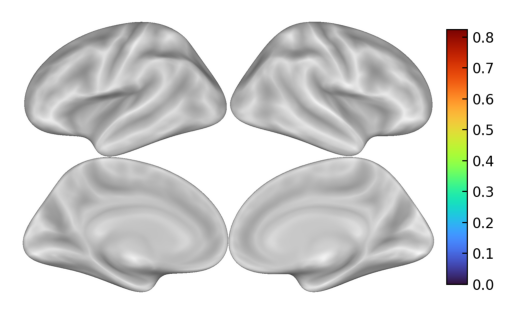

In [9]:
ciftidata=nib.load("/Users/sps253/Desktop/data/group-reho_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii").get_fdata()[0,:]

img=create_montage_figure(roivals=ciftidata,atlasname="cifti91k",colormap="turbo",
                          add_colorbar=True, upscale_factor=2,
                          viewnames=['lateral','medial'],face_mode='best')
plt.figure()
plt.imshow(img)
_=plt.axis('off')

2024-02-27 20:02:56 URL:https://raw.githubusercontent.com/Washington-University/HCPpipelines/master/global/templates/91282_Greyordinates/L.atlasroi.32k_fs_LR.shape.gii [3510/3510] -> "L.atlasroi.32k_fs_LR.shape.gii" [1]
2024-02-27 20:02:56 URL:https://raw.githubusercontent.com/Washington-University/HCPpipelines/master/global/templates/91282_Greyordinates/R.atlasroi.32k_fs_LR.shape.gii [3539/3539] -> "R.atlasroi.32k_fs_LR.shape.gii" [1]
CPU times: user 3.02 s, sys: 117 ms, total: 3.14 s
Wall time: 3.41 s


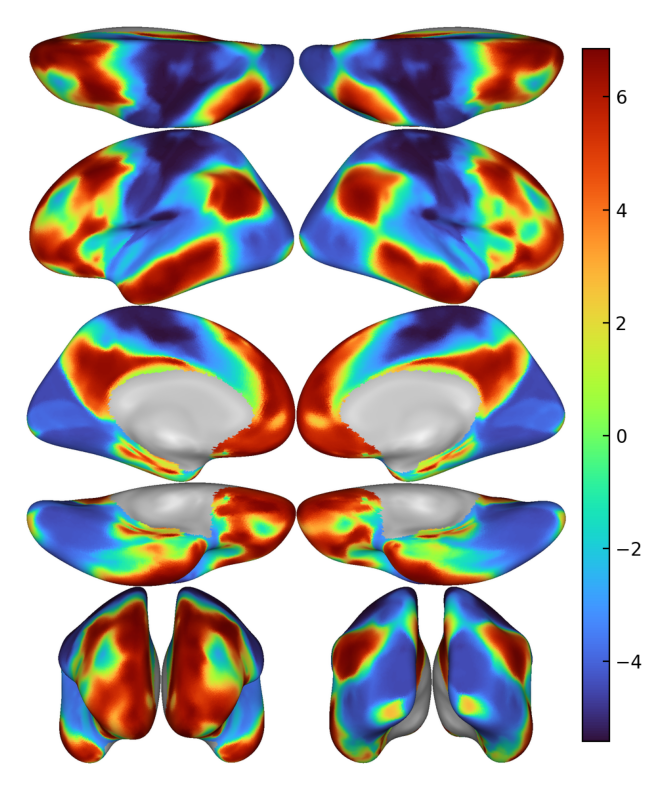

In [14]:
%%time
#example reading and displaying 32k cifti data from neuromaps

if 'neuromaps' not in sys.modules:
  !pip install git+https://github.com/netneurolab/neuromaps.git

from neuromaps import datasets

#fetch fslr 32k fcgradient01 dataset from neuromaps
fcgrad01 = datasets.fetch_annotation(source='margulies2016',desc='fcgradient01',return_single=True)
Ldata=nib.load(fcgrad01[0]).agg_data()
Rdata=nib.load(fcgrad01[1]).agg_data()

#fetch masks to map fslr 32k (full sphere) data to cifti ROI (excludes medial wall)
hcpurl='https://raw.githubusercontent.com/Washington-University/HCPpipelines/master/global/templates/91282_Greyordinates'
!wget -nv -O L.atlasroi.32k_fs_LR.shape.gii {hcpurl}/L.atlasroi.32k_fs_LR.shape.gii
!wget -nv -O R.atlasroi.32k_fs_LR.shape.gii {hcpurl}/R.atlasroi.32k_fs_LR.shape.gii

Lmask=nib.load('L.atlasroi.32k_fs_LR.shape.gii').agg_data()
Rmask=nib.load('R.atlasroi.32k_fs_LR.shape.gii').agg_data()

#concatenate masked LH and RH vertices
ciftidata=np.concatenate((Ldata[Lmask>0],Rdata[Rmask>0]))

img=create_montage_figure(roivals=ciftidata,atlasname="cifti91k",colormap="turbo",
                        upscale_factor=2,add_colorbar=True)

plt.figure(figsize=(10,10))
plt.imshow(img)
_=plt.axis('off')